<a href="https://colab.research.google.com/github/hudayaranjit/IIITK-Internship/blob/main/Suprith.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PAPER 1
# Effective Heart Disease Prediction Using
# Hybrid Machine Learning Techniques
#
# Simplified HRFLM-style demonstration:
# Random Forest + Linear Model
# ============================================================

# 1. Import libraries
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 2. LOAD HEART DISEASE DATASET
# ============================================================

print("Loading Cleveland Heart Disease Dataset...")

heart = fetch_openml(
    name="heart-statlog",
    version=1,
    as_frame=True
)

X = heart.data.copy()
y = heart.target.copy()

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(X.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(y.value_counts())


# ============================================================
# 3. CONVERT TARGET INTO 0 AND 1
# ============================================================

# heart-statlog commonly represents target as:
# "1" = absence
# "2" = presence
#
# We convert:
# 0 = No Heart Disease
# 1 = Heart Disease

y = y.astype(str)

unique_classes = sorted(y.unique())

print("\nOriginal target classes:", unique_classes)

if set(unique_classes) == {"1", "2"}:
    y = y.map({
        "1": 0,
        "2": 1
    })
else:
    # Fallback if OpenML representation changes
    y = pd.factorize(y)[0]

y = pd.Series(y, index=X.index)

print("\nConverted Target:")
print(y.value_counts())


# ============================================================
# 4. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

categorical_features = X.select_dtypes(
    include=["category", "object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["category", "object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 5. DATA PREPROCESSING
# ============================================================

# Numerical:
# Missing values -> median
# Scaling -> StandardScaler

numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# Categorical:
# Missing values -> most frequent
# Convert categories using One-Hot Encoding

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 7. CREATE RANDOM FOREST
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


# ============================================================
# 8. CREATE LINEAR MODEL
# ============================================================

linear_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)


# ============================================================
# 9. HYBRID MODEL
# ============================================================

# Simplified HRFLM-style hybrid:
#
# Random Forest
#       +
# Logistic Regression (linear classifier)
#       ↓
# Soft Voting

hybrid_model = VotingClassifier(
    estimators=[
        ("Random Forest", random_forest),
        ("Linear Model", linear_model)
    ],
    voting="soft"
)


# ============================================================
# 10. COMPLETE PIPELINE
# ============================================================

model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "hybrid_model",
        hybrid_model
    )
])


# ============================================================
# 11. TRAIN MODEL
# ============================================================

print("\nTraining Hybrid Model...")

model.fit(
    X_train,
    y_train
)

print("Training completed!")


# ============================================================
# 12. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 13. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n================================")
print("       PAPER 1 RESULTS")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)


# ============================================================
# 16. SHOW SOME ACTUAL VS PREDICTED RESULTS
# ============================================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Actual"] = results["Actual"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

results["Predicted"] = results["Predicted"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

print("\nSample Predictions:")

print(
    results.head(10)
)

Loading Cleveland Heart Disease Dataset...

Dataset loaded successfully!

Dataset Shape:
(270, 13)

Features:
['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal']

Target Classes:
class
absent     150
present    120
Name: count, dtype: int64

Original target classes: ['absent', 'present']

Converted Target:
1    150
0    120
Name: count, dtype: int64

Numerical Features:
['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal']

Categorical Features:
[]

Training Samples: 216
Testing Samples : 54

Training Hybrid Model...
Training completed!

       PAPER 1 RESULTS
Accuracy  : 0.7778
Precision : 0.8000
Recall 

Loading Heart Disease Dataset...

Dataset loaded successfully!

Dataset Shape:
(270, 13)

Features:
['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal']

Original Target Classes:
['absent', 'present']

Converted Target Distribution:
1    150
0    120
Name: count, dtype: int64

Number of features after encoding:
13

Training Samples: 216
Testing Samples : 54

SELECTED FEATURES
age
chest
serum_cholestoral
resting_electrocardiographic_results
maximum_heart_rate_achieved
exercise_induced_angina
oldpeak
slope
number_of_major_vessels
thal

BEFORE SMOTE
1    120
0     96
Name: count, dtype: int64

AFTER SMOTE
0    120
1    120
Name: count, dtype: int64

Training XGBoost Model...
Training completed!

       PAPER 2 RESULTS
Accuracy  : 0.6667
Precision : 0.7143
Recall    : 0.6667
F1 Score  : 0.6897

Conf

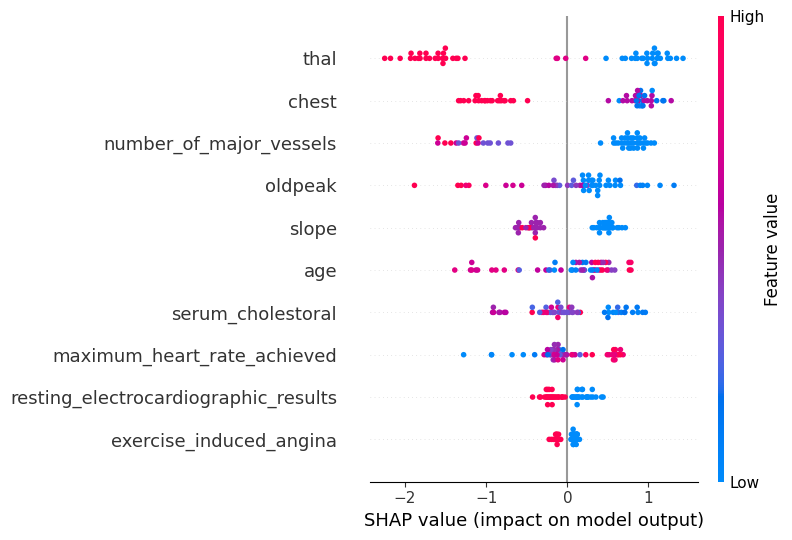

In [ ]:
# ============================================================
# PAPER 2
# Heart Disease Prediction using
# XGBoost + Feature Selection + SMOTE + SHAP
# ============================================================

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD HEART DISEASE DATASET
# ============================================================

print("Loading Heart Disease Dataset...")

heart = fetch_openml(
    name="heart-statlog",
    version=1,
    as_frame=True
)

X = heart.data.copy()
y = heart.target.copy()

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(X.shape)

print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 2. CONVERT TARGET
# ============================================================

y = y.astype(str)

unique_classes = sorted(y.unique())

print("\nOriginal Target Classes:")
print(unique_classes)

if set(unique_classes) == {"1", "2"}:

    y = y.map({
        "1": 0,
        "2": 1
    })

else:

    y = pd.factorize(y)[0]

y = pd.Series(y, index=X.index)


print("\nConverted Target Distribution:")
print(y.value_counts())


# ============================================================
# 3. CONVERT FEATURES TO NUMERIC
# ============================================================

# Convert categorical columns into numerical dummy variables

X = pd.get_dummies(
    X,
    drop_first=False
)

X = X.astype(float)

print("\nNumber of features after encoding:")
print(X.shape[1])


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(
    X_train
)

X_test_imputed = imputer.transform(
    X_test
)


# ============================================================
# 6. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

X_test_scaled = scaler.transform(
    X_test_imputed
)


# ============================================================
# 7. FEATURE SELECTION
# ============================================================

# Select useful features using mutual information

number_of_features = min(
    10,
    X_train_scaled.shape[1]
)

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=number_of_features
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)


selected_mask = selector.get_support()

selected_features = X.columns[
    selected_mask
].tolist()


print("\n================================")
print("SELECTED FEATURES")
print("================================")

for feature in selected_features:
    print(feature)


# ============================================================
# 8. CLASS DISTRIBUTION BEFORE SMOTE
# ============================================================

print("\n================================")
print("BEFORE SMOTE")
print("================================")

print(y_train.value_counts())


# ============================================================
# 9. APPLY SMOTE
# ============================================================

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_selected,
    y_train
)


print("\n================================")
print("AFTER SMOTE")
print("================================")

print(
    pd.Series(
        y_train_balanced
    ).value_counts()
)


# ============================================================
# 10. CREATE XGBOOST MODEL
# ============================================================

model = XGBClassifier(

    n_estimators=200,

    max_depth=3,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)


# ============================================================
# 11. TRAIN XGBOOST
# ============================================================

print("\nTraining XGBoost Model...")

model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Training completed!")


# ============================================================
# 12. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_selected
)


# ============================================================
# 13. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n================================")
print("       PAPER 2 RESULTS")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)


# ============================================================
# 16. SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})


results["Actual"] = results["Actual"].map({

    0: "No Heart Disease",

    1: "Heart Disease"

})


results["Predicted"] = results["Predicted"].map({

    0: "No Heart Disease",

    1: "Heart Disease"

})


print("\n================================")
print("SAMPLE PREDICTIONS")
print("================================")

print(
    results.head(10)
)


# ============================================================
# 17. SHAP EXPLAINABLE AI
# ============================================================

print("\nGenerating SHAP Explanation...")


# Convert test data back into DataFrame
X_test_shap = pd.DataFrame(

    X_test_selected,

    columns=selected_features
)


# Create SHAP explainer
explainer = shap.TreeExplainer(
    model
)


# Calculate SHAP values
shap_values = explainer(
    X_test_shap
)


# ============================================================
# 18. SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(

    shap_values,

    X_test_shap
)

Loading Heart Disease Dataset...

Dataset loaded successfully!

Dataset Shape:
(270, 13)

Features:
['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal']

Original Target Classes:
['absent', 'present']

Converted Target Distribution:
1    150
0    120
Name: count, dtype: int64

Number of input features:
13

Training Samples: 216
Testing Samples : 54

Data preprocessing completed!

ANN ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)


Training Artificial Neural Network...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6105 - loss: 0.6759 - val_accuracy: 0.6591 - val_loss: 0.6257
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6395 - loss: 0.6524 - val_accuracy: 0.7727 - val_loss: 0.6162
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6802 - loss: 0.6318 - val_accuracy: 0.7500 - val_loss: 0.6040
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7093 - loss: 0.6136 - val_accuracy: 0.7500 - val_loss: 0.5937
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7616 - loss: 0.5931 - val_accuracy: 0.7955 - val_loss: 0.5831
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7733 - loss: 0.5728 - val_accuracy: 0.7955 - val_loss: 0.5713
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7849 - loss: 0.5531 - val_accuracy: 0.7955 - val_loss: 0.5596
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8140 - l

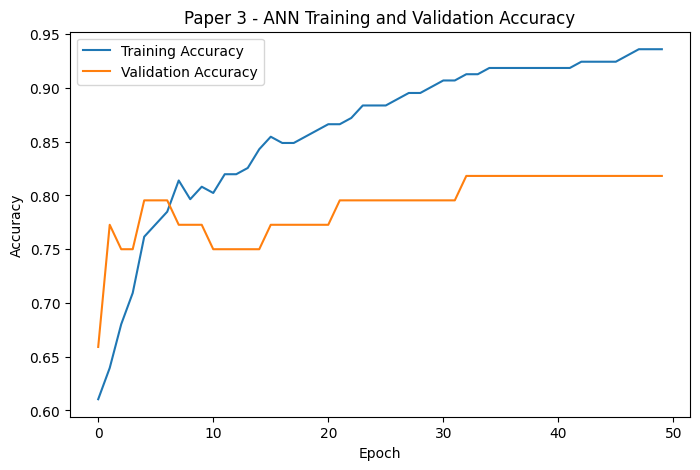

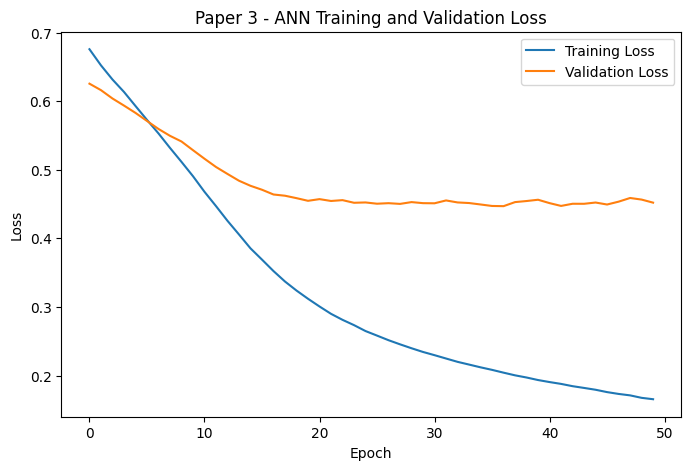

In [ ]:
# ============================================================
# PAPER 3
# Heart Disease Prediction Using
# Artificial Neural Network (ANN)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. LOAD HEART DISEASE DATASET
# ============================================================

print("Loading Heart Disease Dataset...")

heart = fetch_openml(
    name="heart-statlog",
    version=1,
    as_frame=True
)

X = heart.data.copy()
y = heart.target.copy()

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(X.shape)

print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 2. CONVERT TARGET TO 0 AND 1
# ============================================================

y = y.astype(str)

unique_classes = sorted(y.unique())

print("\nOriginal Target Classes:")
print(unique_classes)

# heart-statlog:
# 1 = absence of heart disease
# 2 = presence of heart disease

if set(unique_classes) == {"1", "2"}:

    y = y.map({
        "1": 0,
        "2": 1
    })

else:

    y = pd.factorize(y)[0]

y = pd.Series(y, index=X.index)

print("\nConverted Target Distribution:")
print(y.value_counts())


# ============================================================
# 3. CONVERT CATEGORICAL FEATURES TO NUMERIC
# ============================================================

X = pd.get_dummies(
    X,
    drop_first=False
)

X = X.astype(float)

print("\nNumber of input features:")
print(X.shape[1])


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

imputer = SimpleImputer(
    strategy="median"
)

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# ============================================================
# 6. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData preprocessing completed!")


# ============================================================
# 7. BUILD ARTIFICIAL NEURAL NETWORK
# ============================================================

model = Sequential([

    # Input layer
    Input(shape=(X_train.shape[1],)),

    # Hidden Layer 1
    Dense(
        16,
        activation="relu"
    ),

    # Hidden Layer 2
    Dense(
        8,
        activation="relu"
    ),

    # Output Layer
    Dense(
        1,
        activation="sigmoid"
    )

])


# ============================================================
# 8. COMPILE ANN
# ============================================================

model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


# ============================================================
# 9. DISPLAY ANN ARCHITECTURE
# ============================================================

print("\n================================")
print("ANN ARCHITECTURE")
print("================================")

model.summary()


# ============================================================
# 10. TRAIN ANN
# ============================================================

print("\nTraining Artificial Neural Network...")

history = model.fit(

    X_train,
    y_train,

    epochs=50,

    batch_size=16,

    validation_split=0.20,

    verbose=1
)

print("\nANN training completed!")


# ============================================================
# 11. PREDICT TEST DATA
# ============================================================

y_probability = model.predict(
    X_test,
    verbose=0
)

# Convert probability into 0 or 1
y_pred = (
    y_probability >= 0.5
).astype(int).flatten()


# ============================================================
# 12. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n================================")
print("       PAPER 3 RESULTS")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)


# ============================================================
# 15. SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame({

    "Actual": y_test.values,

    "Probability": y_probability.flatten(),

    "Predicted": y_pred
})

results["Actual"] = results["Actual"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

results["Predicted"] = results["Predicted"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})


print("\n================================")
print("SAMPLE PREDICTIONS")
print("================================")

print(results.head(10))


# ============================================================
# 16. TRAINING ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Paper 3 - ANN Training and Validation Accuracy"
)

plt.legend()

plt.show()


# ============================================================
# 17. TRAINING LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Paper 3 - ANN Training and Validation Loss"
)

plt.legend()

plt.show()

Loading Heart Disease Dataset...

Dataset loaded successfully!

Dataset Shape:
(270, 13)

Original Features:
['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal']

Original Target Classes:
['absent', 'present']

Converted Target Distribution:
1    150
0    120
Name: count, dtype: int64

Number of original encoded features:
13

Training Samples: 216
Testing Samples : 54

Data preprocessing completed!

AUTOENCODER ARCHITECTURE


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ learned_features (Dense)        │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 725 (2.83 KB)

 Trainable params: 725 (2.83 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)


Training Deep Neural Network...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6221 - loss: 0.6450 - val_accuracy: 0.6818 - val_loss: 0.6335
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8081 - loss: 0.5683 - val_accuracy: 0.7045 - val_loss: 0.5642
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8605 - loss: 0.5073 - val_accuracy: 0.7273 - val_loss: 0.5247
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8547 - loss: 0.4543 - val_accuracy: 0.7273 - val_loss: 0.4900
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8605 - loss: 0.4072 - val_accuracy: 0.7727 - val_loss: 0.4671
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8721 - loss: 0.3687 - val_accuracy: 0.7727 - val_loss: 0.4518
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8721 - loss: 0.3387 - val_accuracy: 0.7727 - val_loss: 0.4492
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8779 - loss: 

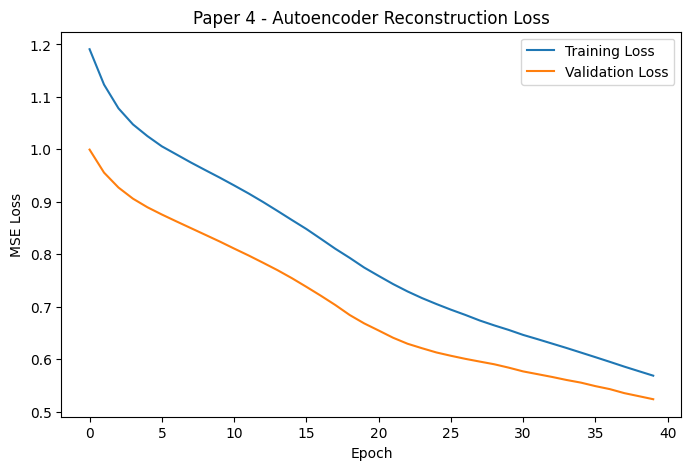

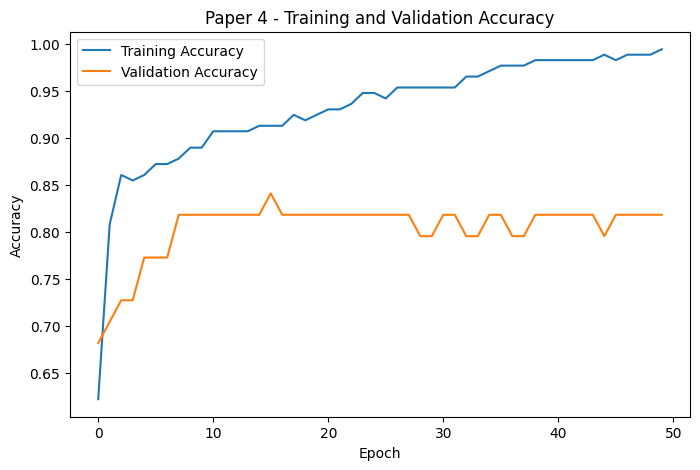

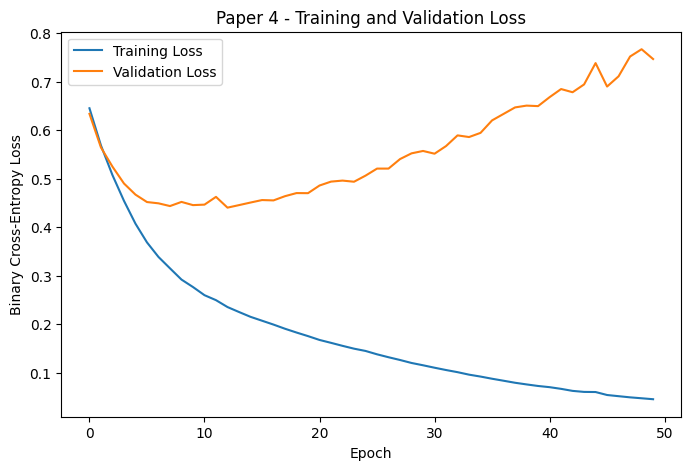

In [ ]:
# ============================================================
# PAPER 4
# Heart Disease Risk Prediction using
# Deep Learning + Feature Augmentation
#
# Educational implementation:
# Autoencoder + Augmented Features + Deep Neural Network
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Concatenate
)
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. LOAD HEART DISEASE DATASET
# ============================================================

print("Loading Heart Disease Dataset...")

heart = fetch_openml(
    name="heart-statlog",
    version=1,
    as_frame=True
)

X = heart.data.copy()
y = heart.target.copy()

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(X.shape)

print("\nOriginal Features:")
print(X.columns.tolist())


# ============================================================
# 2. CONVERT TARGET TO 0 AND 1
# ============================================================

y = y.astype(str)

unique_classes = sorted(y.unique())

print("\nOriginal Target Classes:")
print(unique_classes)

# heart-statlog:
# 1 = absence of heart disease
# 2 = presence of heart disease

if set(unique_classes) == {"1", "2"}:

    y = y.map({
        "1": 0,
        "2": 1
    })

else:

    y = pd.factorize(y)[0]

y = pd.Series(y, index=X.index)

print("\nConverted Target Distribution:")
print(y.value_counts())


# ============================================================
# 3. CONVERT CATEGORICAL FEATURES TO NUMERIC
# ============================================================

X = pd.get_dummies(
    X,
    drop_first=False
)

X = X.astype(float)

print("\nNumber of original encoded features:")
print(X.shape[1])


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

imputer = SimpleImputer(
    strategy="median"
)

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# ============================================================
# 6. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData preprocessing completed!")


# ============================================================
# 7. BUILD AUTOENCODER
# ============================================================

# Number of original input features
input_dimension = X_train.shape[1]

# Number of new learned features
encoded_dimension = 8


# Input layer
autoencoder_input = Input(
    shape=(input_dimension,)
)


# Encoder
encoded = Dense(
    16,
    activation="relu"
)(autoencoder_input)

encoded = Dense(
    encoded_dimension,
    activation="relu",
    name="learned_features"
)(encoded)


# Decoder
decoded = Dense(
    16,
    activation="relu"
)(encoded)

decoded = Dense(
    input_dimension,
    activation="linear"
)(decoded)


# Complete Autoencoder
autoencoder = Model(
    inputs=autoencoder_input,
    outputs=decoded
)


# ============================================================
# 8. COMPILE AUTOENCODER
# ============================================================

autoencoder.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="mse"
)


print("\n================================")
print("AUTOENCODER ARCHITECTURE")
print("================================")

autoencoder.summary()


# ============================================================
# 9. TRAIN AUTOENCODER
# ============================================================

print("\nTraining Autoencoder...")

autoencoder_history = autoencoder.fit(

    X_train,
    X_train,

    epochs=40,

    batch_size=16,

    validation_split=0.20,

    verbose=1
)

print("\nAutoencoder training completed!")


# ============================================================
# 10. CREATE ENCODER MODEL
# ============================================================

# Extract only the encoder part

encoder = Model(

    inputs=autoencoder.input,

    outputs=autoencoder.get_layer(
        "learned_features"
    ).output
)


# ============================================================
# 11. GENERATE NEW LEARNED FEATURES
# ============================================================

X_train_learned = encoder.predict(
    X_train,
    verbose=0
)

X_test_learned = encoder.predict(
    X_test,
    verbose=0
)


print("\nShape of learned training features:")
print(X_train_learned.shape)


# ============================================================
# 12. FEATURE AUGMENTATION
# ============================================================

# Combine:
#
# Original Features
#       +
# Learned Features
#
# = Augmented Features


X_train_augmented = np.concatenate(
    [
        X_train,
        X_train_learned
    ],
    axis=1
)


X_test_augmented = np.concatenate(
    [
        X_test,
        X_test_learned
    ],
    axis=1
)


print("\n================================")
print("FEATURE AUGMENTATION")
print("================================")

print(
    "Original Features :",
    X_train.shape[1]
)

print(
    "Learned Features  :",
    X_train_learned.shape[1]
)

print(
    "Augmented Features:",
    X_train_augmented.shape[1]
)


# ============================================================
# 13. BUILD DEEP NEURAL NETWORK
# ============================================================

classifier = Sequential([

    Input(
        shape=(X_train_augmented.shape[1],)
    ),

    # Hidden Layer 1
    Dense(
        32,
        activation="relu"
    ),

    # Hidden Layer 2
    Dense(
        16,
        activation="relu"
    ),

    # Hidden Layer 3
    Dense(
        8,
        activation="relu"
    ),

    # Output Layer
    Dense(
        1,
        activation="sigmoid"
    )

])


# ============================================================
# 14. COMPILE CLASSIFIER
# ============================================================

classifier.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


print("\n================================")
print("DEEP NEURAL NETWORK")
print("================================")

classifier.summary()


# ============================================================
# 15. TRAIN CLASSIFIER
# ============================================================

print("\nTraining Deep Neural Network...")

history = classifier.fit(

    X_train_augmented,
    y_train,

    epochs=50,

    batch_size=16,

    validation_split=0.20,

    verbose=1
)

print("\nDeep Neural Network training completed!")


# ============================================================
# 16. PREDICT TEST DATA
# ============================================================

y_probability = classifier.predict(
    X_test_augmented,
    verbose=0
)


y_pred = (
    y_probability >= 0.5
).astype(int).flatten()


# ============================================================
# 17. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n================================")
print("       PAPER 4 RESULTS")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)


# ============================================================
# 20. SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame({

    "Actual": y_test.values,

    "Probability": y_probability.flatten(),

    "Predicted": y_pred
})


results["Actual"] = results["Actual"].map({

    0: "No Heart Disease",

    1: "Heart Disease"

})


results["Predicted"] = results["Predicted"].map({

    0: "No Heart Disease",

    1: "Heart Disease"

})


print("\n================================")
print("SAMPLE PREDICTIONS")
print("================================")

print(
    results.head(10)
)


# ============================================================
# 21. AUTOENCODER LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    autoencoder_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    autoencoder_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Paper 4 - Autoencoder Reconstruction Loss"
)

plt.legend()

plt.show()


# ============================================================
# 22. CLASSIFIER ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Paper 4 - Training and Validation Accuracy"
)

plt.legend()

plt.show()


# ============================================================
# 23. CLASSIFIER LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "Paper 4 - Training and Validation Loss"
)

plt.legend()

plt.show()